## Examining Multiplane Ophys NWB Files

This notebook demonstrates how to stream and explore processed multiplane 2-photon calcium imaging NWB files from the `s3://aind-open-data` bucket.

### Sections

0. Environment Setup
1. Open NWB from S3
2. Session & Subject Metadata
3. Explore Imaging Planes
4. ROI Segmentation Overview
5. Visualize ROI Masks
6. Plot dF/F Traces
7. Compare Fluorescence Signals
8. Event Detection
9. Multi-Plane Comparison
10. Data Shapes Summary

---

*This notebook was generated with the assistance of Claude (Anthropic).*

## 0. Environment Setup

In [16]:
%pip install boto3 remfile h5py pynwb hdmf-zarr s3fs matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [17]:
import h5py
import remfile
import boto3
import numpy as np
import matplotlib.pyplot as plt
from botocore import UNSIGNED
from botocore.config import Config
from pynwb import NWBHDF5IO

## 1. Open NWB from S3

In [18]:
S3_BUCKET = "aind-open-data"


def _get_s3_client():
    return boto3.client("s3", config=Config(signature_version=UNSIGNED))


def _list_all_keys(prefix, bucket=S3_BUCKET):
    prefix = prefix.rstrip("/") + "/"
    paginator = _get_s3_client().get_paginator("list_objects_v2")
    keys = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            keys.append(obj["Key"])
    return keys


def _find_nwb_in_keys(keys):
    zarr_prefixes = set()
    hdf5_keys = []
    for key in keys:
        if ".nwb.zarr/" in key:
            zarr_prefixes.add(key[: key.index(".nwb.zarr/") + len(".nwb.zarr")])
        elif ".nwb/" in key:
            zarr_prefixes.add(key[: key.index(".nwb/") + len(".nwb")])
        elif key.endswith(".nwb"):
            hdf5_keys.append(key)
    if zarr_prefixes:
        return next(iter(zarr_prefixes)), True
    if hdf5_keys:
        return hdf5_keys[0], False
    return None, None


def open_nwb_from_s3(s3_path, bucket=S3_BUCKET):
    if s3_path.startswith("s3://"):
        s3_path = s3_path[len("s3://"):]
        bucket, _, key = s3_path.partition("/")
    else:
        key = s3_path

    print(f"Searching for NWB file in s3://{bucket}/{key} ...")
    all_keys = _list_all_keys(key, bucket=bucket)
    nwb_key, is_zarr = _find_nwb_in_keys(all_keys)

    if nwb_key is None:
        raise FileNotFoundError(f"No NWB file found under s3://{bucket}/{key}")

    if is_zarr:
        from hdmf_zarr import NWBZarrIO
        print(f"Opening Zarr NWB: s3://{bucket}/{nwb_key}")
        io = NWBZarrIO(
            path=f"s3://{bucket}/{nwb_key}",
            mode="r",
            load_namespaces=True,
            storage_options={"anon": True},
        )
    else:
        print(f"Opening HDF5 NWB: s3://{bucket}/{nwb_key}")
        url = f"https://s3.amazonaws.com/{bucket}/{nwb_key}"
        rem = remfile.File(url)
        h5_file = h5py.File(rem, "r")
        io = NWBHDF5IO(file=h5_file, mode="r", load_namespaces=True)

    return io.read()

In [19]:
SESSION = "multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22"
nwb = open_nwb_from_s3(SESSION)

Searching for NWB file in s3://aind-open-data/multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22 ...
Opening Zarr NWB: s3://aind-open-data/multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22/pophys.nwb.zarr


## 2. Session & Subject Metadata

In [20]:
print(f"Session ID:          {nwb.session_id}")
print(f"Session description: {nwb.session_description}")
print(f"Session start:       {nwb.session_start_time}")
print(f"Institution:         {nwb.institution}")
print(f"Experimenter:        {nwb.experimenter}")
print()

subj = nwb.subject
print(f"Subject ID:          {subj.subject_id}")
print(f"Species:             {subj.species}")
print(f"Sex:                 {subj.sex}")
print(f"Age:                 {subj.age}")
print(f"Genotype:            {subj.genotype}")
print(f"Date of birth:       {subj.date_of_birth}")

Session ID:          multiplane-ophys_837568_2026-03-05_14-14-51
Session description: A Unknown Project  experiment performed using OPTICAL_SESSION3_STANDARD behavior. Experiment includes Planar optical physiology, Behavior videos, Behavior modalities.
Session start:       2026-03-05 14:14:51.960479-08:00
Institution:         Allen Institute for Neural Dynamics
Experimenter:        ("['NSB-1354', 'Jerome Lecoq']",)

Subject ID:          837568
Species:             Mus musculus
Sex:                 M
Age:                 P121D
Genotype:            Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt
Date of birth:       2025-11-04 00:00:00-07:53


## 3. Explore Imaging Planes

This NWB contains 8 imaging planes across two visual areas (VISp and VISl), each at different cortical depths.

In [21]:
plane_names = sorted(nwb.imaging_planes.keys())
print(f"Number of imaging planes: {len(plane_names)}")
print()

for name in plane_names:
    plane = nwb.imaging_planes[name]
    print(f"  {name}:")
    print(f"    location:          {plane.location}")
    print(f"    imaging_rate:      {plane.imaging_rate} Hz")
    print(f"    excitation_lambda: {plane.excitation_lambda} nm")
    print(f"    indicator:         {plane.indicator}")
    print(f"    grid_spacing:      {plane.grid_spacing} {plane.grid_spacing_unit}")
    print(f"    origin_coords:     {plane.origin_coords} {plane.origin_coords_unit}")
    print(f"    device:            {plane.device.name}")
    print()

Number of imaging planes: 8

  VISl_4:
    location:          Structure: VISl Depth: 173
    imaging_rate:      9.48 Hz
    excitation_lambda: 920.0 nm
    indicator:         Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt
    grid_spacing:      <zarr.core.Array '/general/optophysiology/VISl_4/grid_spacing' (2,) float64 read-only> micrometer
    origin_coords:     <zarr.core.Array '/general/optophysiology/VISl_4/origin_coords' (3,) float64 read-only> micrometer
    device:            MESO.1

  VISl_5:
    location:          Structure: VISl Depth: 297
    imaging_rate:      9.48 Hz
    excitation_lambda: 920.0 nm
    indicator:         Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt
    grid_spacing:      <zarr.core.Array '/general/optophysiology/VISl_5/grid_spacing' (2,) float64 read-only> micrometer
    origin_coords:     <zarr.core.Array '/general/optophysiology/VISl_5/origin_coords' (3,) float64 read-only> micrometer
    device:   

## 4. ROI Segmentation Overview

Each processing module contains a `PlaneSegmentation` table with ROI masks and soma/dendrite classification from cellpose.

In [22]:
EXAMPLE_PLANE = plane_names[0]
print(f"Examining ROIs for plane: {EXAMPLE_PLANE}")
print()

proc = nwb.processing[EXAMPLE_PLANE]
roi_table = proc["image_segmentation"]["roi_table"]

n_rois = len(roi_table)
print(f"Total ROIs: {n_rois}")

is_soma = np.array(roi_table["is_soma"].data)
is_dendrite = np.array(roi_table["is_dendrite"].data)
soma_prob = np.array(roi_table["soma_probability"].data)
dendrite_prob = np.array(roi_table["dendrite_probability"].data)

print(f"  Soma ROIs:     {is_soma.sum()}")
print(f"  Dendrite ROIs: {is_dendrite.sum()}")
print(f"  Mean soma probability:     {soma_prob.mean():.3f}")
print(f"  Mean dendrite probability: {dendrite_prob.mean():.3f}")

Examining ROIs for plane: VISl_4

Total ROIs: 353
  Soma ROIs:     335
  Dendrite ROIs: 1
  Mean soma probability:     0.939
  Mean dendrite probability: 0.003


## 5. Visualize ROI Masks

Overlay ROI masks on the average and max projection images for the example plane.

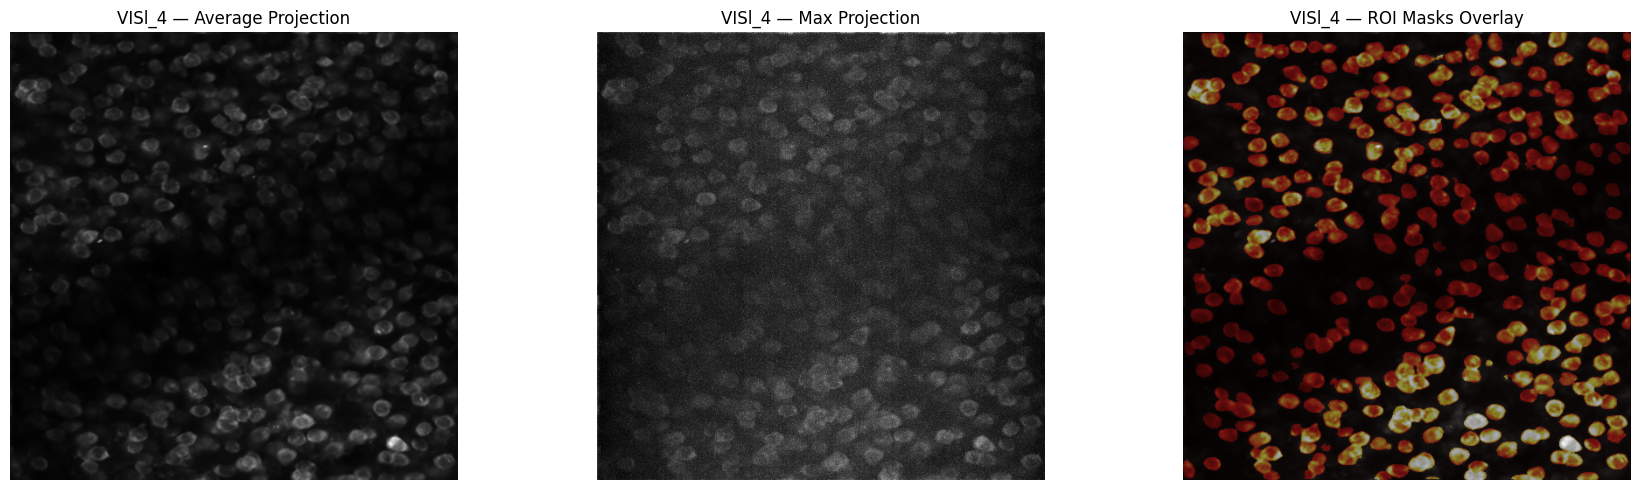

In [23]:
images = proc["images"]
avg_proj = np.array(images["average_projection"].data)
max_proj = np.array(images["max_projection"].data)

# Bulk-load all ROI masks in one S3 read, then take the max
all_masks = np.array(roi_table["image_mask"].data[:])
composite_mask = all_masks.max(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(avg_proj, cmap="gray")
axes[0].set_title(f"{EXAMPLE_PLANE} — Average Projection")
axes[0].axis("off")

axes[1].imshow(max_proj, cmap="gray")
axes[1].set_title(f"{EXAMPLE_PLANE} — Max Projection")
axes[1].axis("off")

axes[2].imshow(avg_proj, cmap="gray")
axes[2].imshow(composite_mask, cmap="hot", alpha=0.4)
axes[2].set_title(f"{EXAMPLE_PLANE} — ROI Masks Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 6. Plot dF/F Traces

Load the `dff_timeseries` for the example plane and plot a few ROI traces.

In [24]:
dff_series = proc["dff_timeseries"]["dff_timeseries"]
dff_data = dff_series.data
dff_timestamps = np.array(dff_series.timestamps)

print(f"dF/F data shape: {dff_data.shape}  (timepoints x ROIs)")
print(f"Duration: {dff_timestamps[-1] - dff_timestamps[0]:.1f} seconds")
print(f"Sampling rate: {1 / np.median(np.diff(dff_timestamps)):.2f} Hz")

dF/F data shape: (41307, 353)  (timepoints x ROIs)
Duration: 4357.7 seconds
Sampling rate: 9.48 Hz


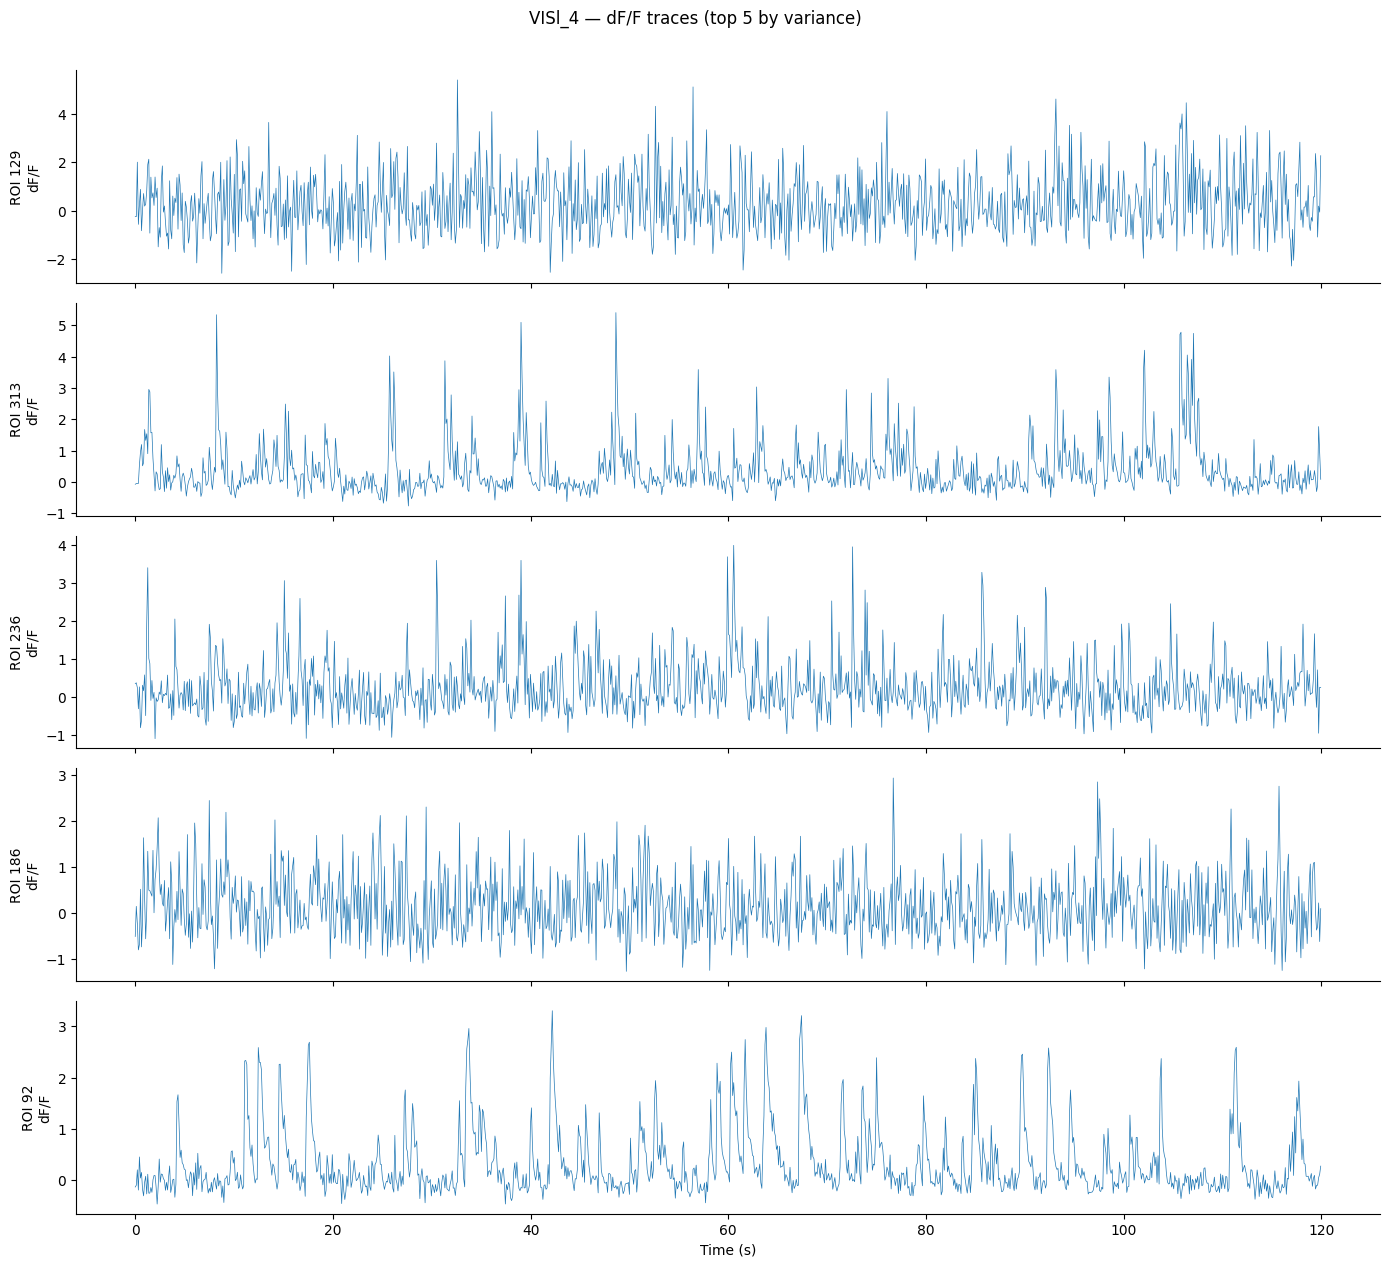

In [25]:
N_ROIS_TO_PLOT = 5
TIME_WINDOW = (0, 120)  # seconds from start

t0 = dff_timestamps[0]
time_mask = (dff_timestamps - t0 >= TIME_WINDOW[0]) & (dff_timestamps - t0 <= TIME_WINDOW[1])
idx_start = np.argmax(time_mask)
idx_end = len(time_mask) - np.argmax(time_mask[::-1])
t_plot = dff_timestamps[idx_start:idx_end] - t0

# Pick ROIs with high variance (likely responsive)
snippet = np.array(dff_data[:1000, :])
variances = np.var(snippet, axis=0)
top_rois = np.argsort(variances)[-N_ROIS_TO_PLOT:][::-1]

fig, axes = plt.subplots(N_ROIS_TO_PLOT, 1, figsize=(14, 2.5 * N_ROIS_TO_PLOT), sharex=True)

for ax, roi_idx in zip(axes, top_rois):
    trace = np.array(dff_data[idx_start:idx_end, int(roi_idx)])
    ax.plot(t_plot, trace, linewidth=0.5)
    ax.set_ylabel(f"ROI {roi_idx}\ndF/F")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{EXAMPLE_PLANE} — dF/F traces (top {N_ROIS_TO_PLOT} by variance)", y=1.01)
plt.tight_layout()
plt.show()

## 7. Compare Fluorescence Signals

For a single ROI, compare the raw fluorescence, neuropil fluorescence, neuropil-corrected, and dF/F signals.

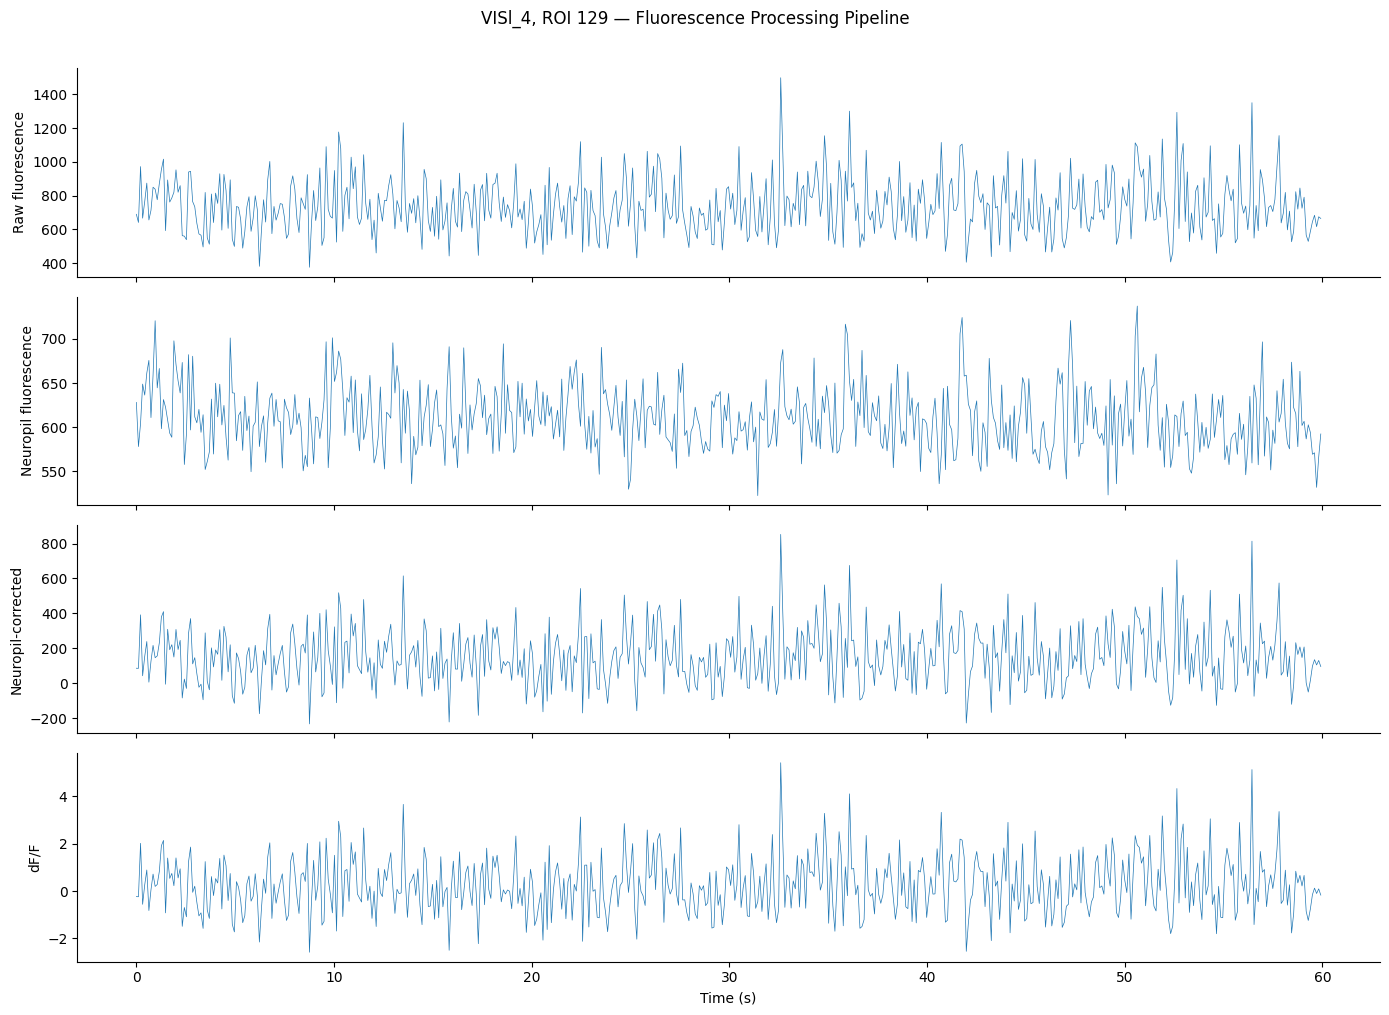

In [26]:
ROI_IDX = int(top_rois[0])
COMPARE_WINDOW = (0, 60)  # seconds

raw_series = proc["raw_timeseries"]["ROI_fluorescence_timeseries"]
neuropil_series = proc["neuropil_fluorescence_timeseries"]
corrected_series = proc["neuropil_corrected_timeseries"]

raw_ts = np.array(raw_series.timestamps)
raw_mask = (raw_ts - raw_ts[0] >= COMPARE_WINDOW[0]) & (raw_ts - raw_ts[0] <= COMPARE_WINDOW[1])
raw_start = np.argmax(raw_mask)
raw_end = len(raw_mask) - np.argmax(raw_mask[::-1])
t_compare = raw_ts[raw_start:raw_end] - raw_ts[0]

dff_cmp_mask = (dff_timestamps - t0 >= COMPARE_WINDOW[0]) & (dff_timestamps - t0 <= COMPARE_WINDOW[1])
dff_start = np.argmax(dff_cmp_mask)
dff_end = len(dff_cmp_mask) - np.argmax(dff_cmp_mask[::-1])
t_dff = dff_timestamps[dff_start:dff_end] - t0

signals = {
    "Raw fluorescence": (t_compare, np.array(raw_series.data[raw_start:raw_end, ROI_IDX])),
    "Neuropil fluorescence": (t_compare, np.array(neuropil_series.data[raw_start:raw_end, ROI_IDX])),
    "Neuropil-corrected": (t_compare, np.array(corrected_series.data[raw_start:raw_end, ROI_IDX])),
    "dF/F": (t_dff, np.array(dff_data[dff_start:dff_end, ROI_IDX])),
}

fig, axes = plt.subplots(len(signals), 1, figsize=(14, 2.5 * len(signals)), sharex=True)

for ax, (label, (t, sig)) in zip(axes, signals.items()):
    ax.plot(t, sig, linewidth=0.5)
    ax.set_ylabel(label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{EXAMPLE_PLANE}, ROI {ROI_IDX} — Fluorescence Processing Pipeline", y=1.01)
plt.tight_layout()
plt.show()

## 8. Event Detection

Overlay detected events on the dF/F trace for a few ROIs.

Event data shape: (41307, 353)


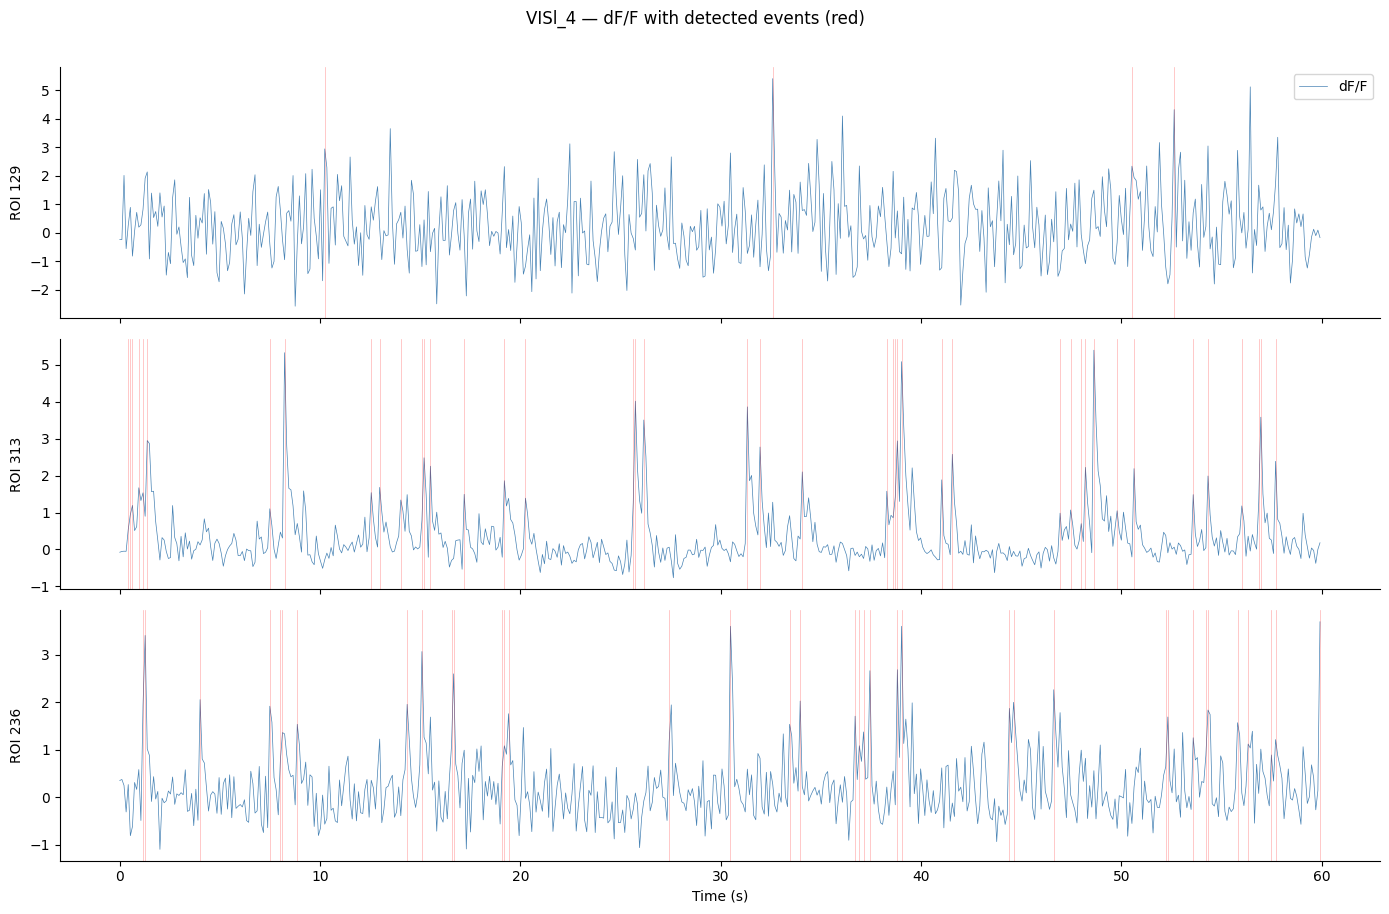

In [28]:
event_series = proc["event_timeseries"]
event_data = event_series.data
event_ts = np.array(event_series.timestamps)

print(f"Event data shape: {event_data.shape}")

EVENT_WINDOW = (0, 60)  # seconds
N_EVENT_ROIS = 3

evt_mask = (event_ts - event_ts[0] >= EVENT_WINDOW[0]) & (event_ts - event_ts[0] <= EVENT_WINDOW[1])
evt_start = np.argmax(evt_mask)
evt_end = len(evt_mask) - np.argmax(evt_mask[::-1])
t_evt = event_ts[evt_start:evt_end] - event_ts[0]

dff_evt_mask = (dff_timestamps - t0 >= EVENT_WINDOW[0]) & (dff_timestamps - t0 <= EVENT_WINDOW[1])
dff_evt_start = np.argmax(dff_evt_mask)
dff_evt_end = len(dff_evt_mask) - np.argmax(dff_evt_mask[::-1])
t_dff_evt = dff_timestamps[dff_evt_start:dff_evt_end] - t0

fig, axes = plt.subplots(N_EVENT_ROIS, 1, figsize=(14, 3 * N_EVENT_ROIS), sharex=True)

for ax, roi_idx in zip(axes, top_rois[:N_EVENT_ROIS]):
    roi_idx = int(roi_idx)
    dff_trace = np.array(dff_data[dff_evt_start:dff_evt_end, roi_idx])
    evt_trace = np.array(event_data[evt_start:evt_end, roi_idx])

    ax.plot(t_dff_evt, dff_trace, linewidth=0.5, label="dF/F", color="steelblue")

    # Mark event times as vertical lines
    event_times = t_evt[evt_trace > 0]
    for et in event_times:
        ax.axvline(et, color="red", alpha=0.3, linewidth=0.5)

    ax.set_ylabel(f"ROI {roi_idx}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{EXAMPLE_PLANE} — dF/F with detected events (red)", y=1.01)
plt.tight_layout()
plt.show()

## 9. Multi-Plane Comparison

Compare ROI counts and show average projections across all 8 imaging planes.

In [29]:
plane_stats = []
for name in plane_names:
    p = nwb.processing[name]
    rt = p["image_segmentation"]["roi_table"]
    n = len(rt)
    n_soma = int(np.array(rt["is_soma"].data).sum())
    n_dendrite = int(np.array(rt["is_dendrite"].data).sum())
    plane_stats.append((name, n, n_soma, n_dendrite))

print(f"{'Plane':<12} {'Total ROIs':>10} {'Soma':>8} {'Dendrite':>10}")
print("-" * 42)
for name, n, ns, nd in plane_stats:
    print(f"{name:<12} {n:>10} {ns:>8} {nd:>10}")
print("-" * 42)
print(f"{'TOTAL':<12} {sum(x[1] for x in plane_stats):>10} {sum(x[2] for x in plane_stats):>8} {sum(x[3] for x in plane_stats):>10}")

Plane        Total ROIs     Soma   Dendrite
------------------------------------------
VISl_4              353      335          1
VISl_5              249      240          1
VISl_6              130      121          0
VISl_7              248      232          0
VISp_0              386      361          0
VISp_1              458      397          0
VISp_2              130      119          2
VISp_3              263      250          0
------------------------------------------
TOTAL              2217     2055          4


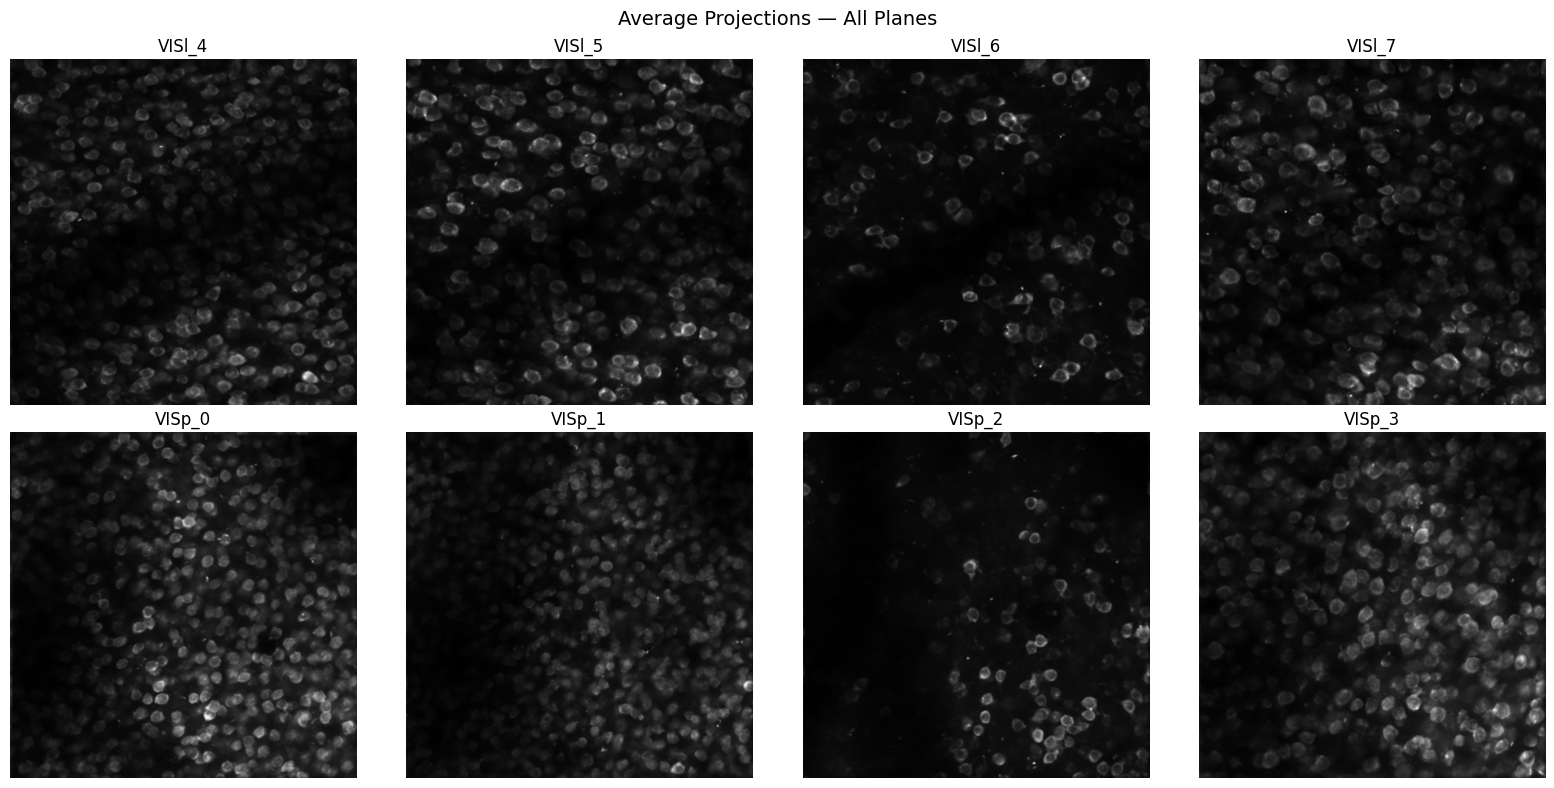

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, name in zip(axes.flat, plane_names):
    avg = np.array(nwb.processing[name]["images"]["average_projection"].data)
    ax.imshow(avg, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

fig.suptitle("Average Projections — All Planes", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Data Shapes Summary

Quick reference table showing the shape of every timeseries in the NWB.

In [31]:
timeseries_keys = [
    ("dff_timeseries", "dff_timeseries"),
    ("event_timeseries", None),
    ("neuropil_corrected_timeseries", None),
    ("neuropil_fluorescence_timeseries", None),
    ("raw_timeseries", "ROI_fluorescence_timeseries"),
]

print(f"{'Plane':<12} {'Timeseries':<38} {'Shape'}")
print("=" * 75)

for name in plane_names:
    p = nwb.processing[name]
    for ts_key, sub_key in timeseries_keys:
        try:
            ts = p[ts_key][sub_key] if sub_key else p[ts_key]
            shape = ts.data.shape
            label = f"{ts_key}/{sub_key}" if sub_key else ts_key
            print(f"{name:<12} {label:<38} {shape}")
        except Exception as e:
            label = f"{ts_key}/{sub_key}" if sub_key else ts_key
            print(f"{name:<12} {label:<38} ERROR: {e}")
    print()

Plane        Timeseries                             Shape
VISl_4       dff_timeseries/dff_timeseries          (41307, 353)
VISl_4       event_timeseries                       (41307, 353)
VISl_4       neuropil_corrected_timeseries          (41307, 353)
VISl_4       neuropil_fluorescence_timeseries       (41307, 353)
VISl_4       raw_timeseries/ROI_fluorescence_timeseries (41307, 353)

VISl_5       dff_timeseries/dff_timeseries          (41307, 249)
VISl_5       event_timeseries                       (41307, 249)
VISl_5       neuropil_corrected_timeseries          (41307, 249)
VISl_5       neuropil_fluorescence_timeseries       (41307, 249)
VISl_5       raw_timeseries/ROI_fluorescence_timeseries (41307, 249)

VISl_6       dff_timeseries/dff_timeseries          (41307, 130)
VISl_6       event_timeseries                       (41307, 130)
VISl_6       neuropil_corrected_timeseries          (41307, 130)
VISl_6       neuropil_fluorescence_timeseries       (41307, 130)
VISl_6       raw_times